## STEP 1: Dataset Load

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bravehart101/sample-supermarket-dataset")

print("Path to dataset files:", path)


100%|██████████| 164k/164k [00:00<00:00, 215kB/s]

Extracting files...
Path to dataset files: C:\Users\kprsv\.cache\kagglehub\datasets\bravehart101\sample-supermarket-dataset\versions\1


## STEP 2: EDA 

In [23]:
import numpy as np 
import pandas as pd 

df = pd.read_csv(r'C:\Users\kprsv\.cache\kagglehub\datasets\bravehart101\sample-supermarket-dataset\versions\1\SampleSuperstore.csv')

In [32]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [18]:
df.duplicated().sum()

17

In [19]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [21]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

## STEP 3: Business Insights 

1. Region wise analysis

In [40]:
df.groupby('Region')[['Sales','Profit']].sum().sort_values(by='Sales',ascending=False)

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


2. State wise analysis

In [37]:
df.groupby('State')[['Sales','Profit']].sum().sort_values(by='Sales', ascending=False)

,Sales,Profit
State,,
California,457687.6315,76381.3871
New York,310876.2710,74038.5486
Texas,170188.0458,-25729.3563
Washington,138641.2700,33402.6517
Pennsylvania,116511.9140,-15559.9603
Florida,89473.7080,-3399.3017
Illinois,80166.1010,-12607.8870
Ohio,78258.1360,-16971.3766
Michigan,76269.6140,24463.1876


3. City wise analysis

In [35]:
df.groupby('City')[['Sales','Profit']].sum().sort_values(by='Sales', ascending=False).head(10)

,Sales,Profit
City,,
New York City,256368.1610,62036.9837
Los Angeles,175851.3410,30440.7579
Seattle,119540.7420,29156.0967
San Francisco,112669.0920,17507.3854
Philadelphia,109077.0130,-13837.7674
Houston,64504.7604,-10153.5485
Chicago,48539.5410,-6654.5688
San Diego,47521.0290,6377.1960
Jacksonville,44713.1830,-2323.8350


4. Category wise analysis

In [43]:
df.groupby('Category')[['Sales','Profit']].sum().sort_values(by='Sales',ascending=False)

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


5. Category → Sub-Category

In [50]:
df.groupby(['Category','Sub-Category'])[['Sales','Profit']].sum()

Sales      Profit
Category        Sub-Category                         
Furniture       Bookcases     114879.9963  -3472.5560
                Chairs        328449.1030  26590.1663
                Furnishings    91705.1640  13059.1436
                Tables        206965.5320 -17725.4811
Office Supplies Appliances    107532.1610  18138.0054
                Art            27118.7920   6527.7870
                Binders       203412.7330  30221.7633
                Envelopes      16476.4020   6964.1767
                Fasteners       3024.2800    949.5182
                Labels         12486.3120   5546.2540
                Paper          78479.2060  34053.5693
                Storage       223843.6080  21278.8264
                Supplies       46673.5380  -1189.0995
Technology      Accessories   167380.3180  41936.6357
                Copiers       149528.0300  55617.8249
                Machines      189238.6310   3384.7569
                Phones        330007.0540  44515.7306

## STEP 4 → Data Visualization

1. Region-wise Sales & Profit

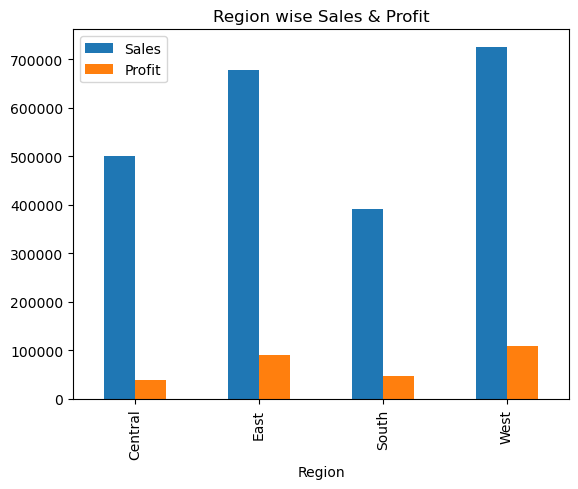

In [51]:
import matplotlib.pyplot as plt

df.groupby('Region')[['Sales','Profit']].sum().plot(kind='bar')
plt.title("Region wise Sales & Profit")
plt.show()

2. Category-wise Performance

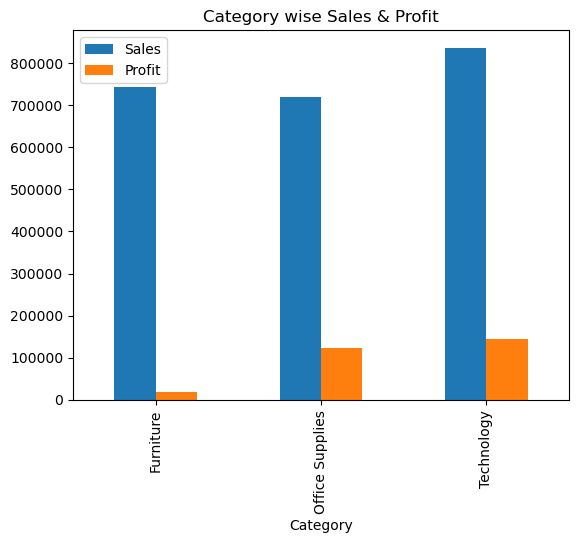

In [52]:
df.groupby('Category')[['Sales','Profit']].sum().plot(kind='bar')
plt.title("Category wise Sales & Profit")
plt.show()

3. Top 10 States (Sales)

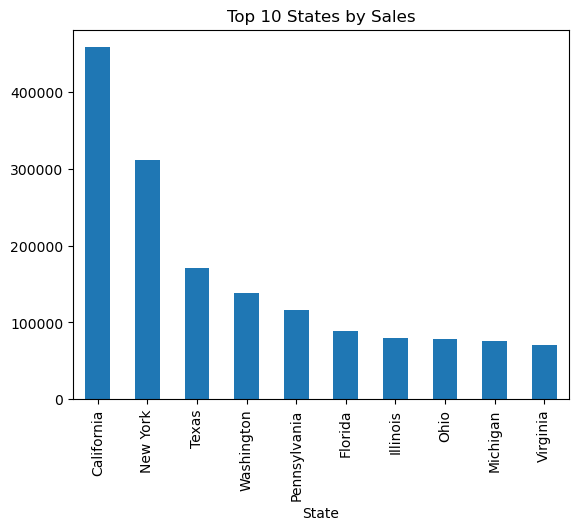

In [53]:
df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 States by Sales")
plt.show()

4. Profit vs Loss Analysis

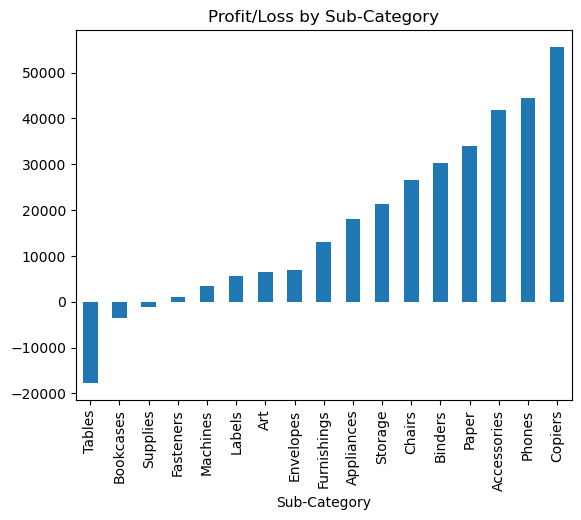

In [54]:
df.groupby('Sub-Category')['Profit'].sum().sort_values().plot(kind='bar')
plt.title("Profit/Loss by Sub-Category")
plt.show()

5. Sales Distribution

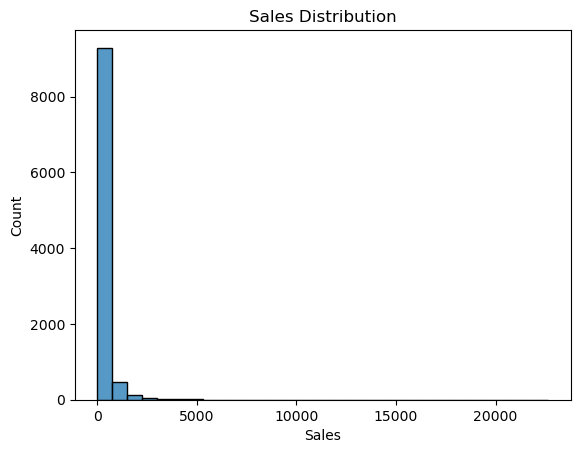

In [55]:
import seaborn as sns

sns.histplot(df['Sales'], bins=30)
plt.title("Sales Distribution")
plt.show()

## STEP 5 → Feature Engineering

In [56]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [59]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [61]:
df['Profit_Margin']= df['Profit']/df['Sales']

In [62]:
df['Profit_Category']=df['Profit'].apply(lambda x:1 if x>0 else 0)

In [63]:
df['Revenue']=df['Sales']*df['Quantity']

In [64]:
df['DiscountImpact'] = df['Sales'] * df['Discount']

In [65]:
df['PricePerUnit'] = df['Sales'] / df['Quantity']

In [66]:
cols=['Ship Mode','Segment','Region','Category','Sub-Category','State','City']
df_encoded=pd.get_dummies(df,columns=cols)

In [94]:
df.head()

,Ship Mode,Segment,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Profit_Margin,Profit_Category,Revenue,DiscountImpact,PricePerUnit
0,Second Class,Consumer,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,0.1600,1,523.9200,0.000000,130.9800
1,Second Class,Consumer,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820,0.3000,1,2195.8200,0.000000,243.9800
2,Second Class,Corporate,California,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,0.4700,1,29.2400,0.000000,7.3100
3,Standard Class,Consumer,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310,-0.4000,0,4787.8875,430.909875,191.5155
4,Standard Class,Consumer,Florida,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,0.1125,1,44.7360,4.473600,11.1840


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ship Mode        9994 non-null   object 
 1   Segment          9994 non-null   object 
 2   Country          9994 non-null   object 
 3   City             9994 non-null   object 
 4   State            9994 non-null   object 
 5   Postal Code      9994 non-null   int64  
 6   Region           9994 non-null   object 
 7   Category         9994 non-null   object 
 8   Sub-Category     9994 non-null   object 
 9   Sales            9994 non-null   float64
 10  Quantity         9994 non-null   int64  
 11  Discount         9994 non-null   float64
 12  Profit           9994 non-null   float64
 13  Profit_Margin    9994 non-null   float64
 14  Profit_Category  9994 non-null   int64  
 15  Revenue          9994 non-null   float64
 16  DiscountImpact   9994 non-null   float64
 17  PricePerUnit  

In [73]:
df=df.drop('Country',axis=1)

In [74]:
df.head()

,Ship Mode,Segment,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Profit_Margin,Profit_Category,Revenue,DiscountImpact,PricePerUnit
0,Second Class,Consumer,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,0.1600,1,523.9200,0.000000,130.9800
1,Second Class,Consumer,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,0.3000,1,2195.8200,0.000000,243.9800
2,Second Class,Corporate,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,0.4700,1,29.2400,0.000000,7.3100
3,Standard Class,Consumer,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,-0.4000,0,4787.8875,430.909875,191.5155
4,Standard Class,Consumer,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,0.1125,1,44.7360,4.473600,11.1840


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ship Mode        9994 non-null   object 
 1   Segment          9994 non-null   object 
 2   City             9994 non-null   object 
 3   State            9994 non-null   object 
 4   Postal Code      9994 non-null   int64  
 5   Region           9994 non-null   object 
 6   Category         9994 non-null   object 
 7   Sub-Category     9994 non-null   object 
 8   Sales            9994 non-null   float64
 9   Quantity         9994 non-null   int64  
 10  Discount         9994 non-null   float64
 11  Profit           9994 non-null   float64
 12  Profit_Margin    9994 non-null   float64
 13  Profit_Category  9994 non-null   int64  
 14  Revenue          9994 non-null   float64
 15  DiscountImpact   9994 non-null   float64
 16  PricePerUnit     9994 non-null   float64
dtypes: float64(7),

## STEP 6 → Train ML Model

In [95]:
X = df[['Ship Mode','Segment','Region',
        'Category','Sub-Category',
        'Sales','Quantity','Discount']]

In [96]:
X = pd.get_dummies(X, drop_first=True)

y = df['Profit_Category']

In [98]:
df=df.drop(['State','Profit','Profit_Margin',
            'Profit_Category','Revenue','DiscountImpact',
           'PricePerUnit'],axis=1)

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Region        9994 non-null   object 
 3   Category      9994 non-null   object 
 4   Sub-Category  9994 non-null   object 
 5   Sales         9994 non-null   float64
 6   Quantity      9994 non-null   int64  
 7   Discount      9994 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 624.8+ KB


In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42)

In [101]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

In [102]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [103]:
y_pred = rf.predict(X_test)

In [104]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9403134378126042


In [105]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.81      0.83       547
           1       0.96      0.97      0.96      2452

    accuracy                           0.94      2999
   macro avg       0.91      0.89      0.90      2999
weighted avg       0.94      0.94      0.94      2999



In [106]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[ 441  106]
 [  73 2379]]


Meaning:

Actual	Predicted
Loss correctly predicted->	441

Loss predicted as profit->	106

Profit predicted as loss->	73

Profit correctly predicted->	2379

In [107]:
importance = rf.feature_importances_

In [108]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

In [109]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [110]:
feature_importance.head(10)

,Feature,Importance
2,Discount,0.532979
0,Sales,0.163942
1,Quantity,0.061513
15,Sub-Category_Binders,0.030202
28,Sub-Category_Tables,0.020224
10,Region_West,0.018223
26,Sub-Category_Storage,0.017186
24,Sub-Category_Paper,0.014795
8,Region_East,0.013035
6,Segment_Corporate,0.012551


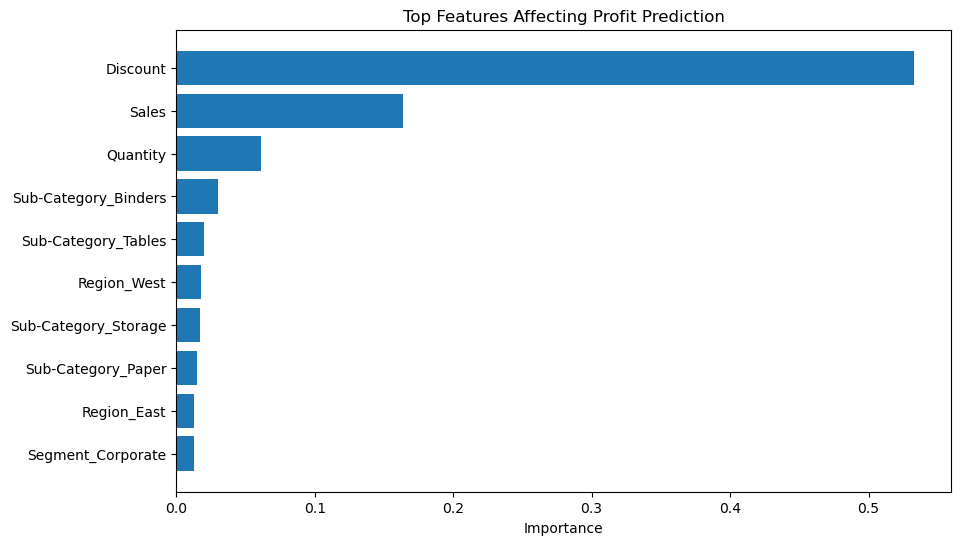

In [111]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top_features['Feature'],
         top_features['Importance'])      #Horizontal bar chart bana rahe ho.

plt.gca().invert_yaxis()

plt.title("Top Features Affecting Profit Prediction")

plt.xlabel("Importance")

plt.show()

## STEP 8 → Cross Validation

In [112]:
from sklearn.model_selection import cross_val_score

In [113]:
cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

In [114]:
print(cv_scores)

[0.93646823 0.94097049 0.94247124 0.94047024 0.94344344]


In [115]:
print("Average CV Score:", cv_scores.mean())

Average CV Score: 0.9407647267076982


## STEP 9 → Hyperparameter Tuning

In [116]:
from sklearn.model_selection import GridSearchCV

In [117]:
params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

In [118]:
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=3
)

In [119]:
grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, None], 'n_estimators': [50, 100]})

In [120]:
print(grid.best_params_)

{'max_depth': None, 'n_estimators': 100}


In [121]:
print(grid.best_score_)

0.9438165806090334


## Usage of Best Model 

In [122]:
best_model=grid.best_estimator_

In [123]:
y_pred_best=best_model.predict(X_test)

In [124]:
from sklearn.metrics import accuracy_score

print("Tuned Accuracy:",
      accuracy_score(y_test, y_pred_best))

Tuned Accuracy: 0.9403134378126042


## SAVING 

In [125]:
import pickle 

In [126]:
pickle.dump(best_model,open("profit_prediction_model.pkl","wb"))

In [127]:
pickle.dump(X.columns,open("model_columns.pkl","wb"))

In [128]:
loaded_model = pickle.load(open("profit_prediction_model.pkl", "rb"))
loaded_columns = pickle.load(open("model_columns.pkl", "rb"))

loaded_model.predict(X_test.head(1))

array([0], dtype=int64)

In [129]:
df.to_csv(r"C:\Users\kprsv\Retail-Sales-Intelligence-System\retail_sales_final.csv", index=False)